`conda activate multi_integration`

# Joint analysis of paired and unpaired multiomic data with Multigrate

In [1]:
import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import numpy as np
import scglue
import muon
import multigrate as mtg
import anndata as ad

[rank: 0] Global seed set to 0


In [2]:
import torch

# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available")
    
    # Get the number of available GPUs
    num_gpus = torch.cuda.device_count()
    print(f"Number of available GPUs: {num_gpus}")
    
    # Get the name of each available GPU
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("CUDA is not available")

CUDA is available
Number of available GPUs: 1
GPU 0: NVIDIA A100-SXM4-40GB


### Loading RNA files

In [3]:
adata_rna_multiome = sc.read('data/subset_rna_multi_dmg_atlas.h5ad')
adata_rna_multiome

AnnData object with n_obs × n_vars = 17875 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [4]:
scglue.data.get_gene_annotation(
    adata_rna_multiome, gtf="/home/cruiz2/software/refdata-gex-GRCh38-2020-A/genes/genes.gtf",
    gtf_by="gene_name"
)
adata_rna_multiome.var.loc[:, ["chrom", "chromStart", "chromEnd"]].head()

,chrom,chromStart,chromEnd
A1BG,chr19,58345177,58353492
A1CF,chr10,50799408,50885675
A2M,chr12,9067663,9116229
A2ML1,chr12,8822620,8887001
A3GALT2,chr1,33306765,33321098


In [5]:
# Define a dictionary mapping old names to new names
name_mapping = {
    "chrom": "chr",
    "chromStart": "start",
    "chromEnd": "end",
    # Add more mappings as needed
}

# Iterate over the dictionary and update column names in `.var` attribute
for old_name, new_name in name_mapping.items():
    if old_name in adata_rna_multiome.var.columns:
        adata_rna_multiome.var.rename(columns={old_name: new_name}, inplace=True)

In [6]:
adata_rna_multiome.obs['Modality'] = 'multiome'

In [7]:
 adata_rna_multiome.var.columns

Index(['vst.mean', 'vst.variance', 'vst.variance.expected',
       'vst.variance.standardized', 'vst.variable', 'chr', 'start', 'end',
       'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb',
       'blockCount', 'blockSizes', 'blockStarts', 'gene_id', 'gene_version',
       'gene_type', 'hgnc_id', 'tag', 'havana_gene'],
      dtype='object')

In [8]:
 adata_rna_multiome.var

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable,chr,start,end,name,score,...,itemRgb,blockCount,blockSizes,blockStarts,gene_id,gene_version,gene_type,hgnc_id,tag,havana_gene
A1BG,0.631716,1202.719885,373.474371,3.220355,True,chr19,58345177,58353492,A1BG,.,...,.,.,.,.,ENSG00000121410,12,protein_coding,HGNC:5,overlapping_locus,OTTHUMG00000183507.3
A1CF,0.068691,39.460411,37.081347,1.064158,False,chr10,50799408,50885675,A1CF,.,...,.,.,.,.,ENSG00000148584,15,protein_coding,HGNC:24086,overlapping_locus,OTTHUMG00000018240.6
A2M,5.611721,15361.999192,7507.142953,2.046318,False,chr12,9067663,9116229,A2M,.,...,.,.,.,.,ENSG00000175899,14,protein_coding,HGNC:7,NaN,OTTHUMG00000150267.7
A2ML1,0.252424,449.444287,142.899698,3.138113,True,chr12,8822620,8887001,A2ML1,.,...,.,.,.,.,ENSG00000166535,20,protein_coding,HGNC:23336,NaN,OTTHUMG00000128499.9
A3GALT2,0.042899,6.267352,22.382860,0.280007,False,chr1,33306765,33321098,A3GALT2,.,...,.,.,.,.,ENSG00000184389,9,protein_coding,HGNC:30005,NaN,OTTHUMG00000004125.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,0.951246,140.007451,645.848580,0.216781,False,chr3,126437600,126475891,ZXDC,.,...,.,.,.,.,ENSG00000070476,15,protein_coding,HGNC:28160,NaN,OTTHUMG00000162754.5
ZYG11A,0.106132,6.651288,58.858057,0.113006,False,chr1,52842510,52894998,ZYG11A,.,...,.,.,.,.,ENSG00000203995,10,protein_coding,HGNC:32058,NaN,OTTHUMG00000008923.5
ZYG11B,0.754683,133.808588,468.050648,0.285885,False,chr1,52726452,52827336,ZYG11B,.,...,.,.,.,.,ENSG00000162378,13,protein_coding,HGNC:25820,ncRNA_host,OTTHUMG00000008938.2
ZYX,1.141768,783.297052,827.634991,0.946428,False,chr7,143381294,143391111,ZYX,.,...,.,.,.,.,ENSG00000159840,16,protein_coding,HGNC:13200,ncRNA_host,OTTHUMG00000023822.11


In [9]:
adata_rna = sc.read('data/subset_rna_only_dmg_atlas.h5ad')
adata_rna

AnnData object with n_obs × n_vars = 31118 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [10]:
adata_rna.obs['Modality'] = 'rna'

### RNA-seq preprocessing

In [11]:
rna = ad.concat([adata_rna_multiome, adata_rna], index_unique = None)
rna

AnnData object with n_obs × n_vars = 48993 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [12]:
rna.layers['counts'] = rna.X.copy()
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=5000, batch_key='Study')

In [13]:
rna = rna[:, rna.var.highly_variable].copy()
rna

AnnData object with n_obs × n_vars = 48993 × 5000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample'

In [14]:
rna.X, rna.X.data

(<48993x5000 sparse matrix of type '<class 'numpy.float64'>'
 	with 21679928 stored elements in Compressed Sparse Row format>,
 array([0.20195362, 0.20195362, 0.10606633, ..., 3.93182563, 3.25809654,
        3.25809654]))

In [16]:
rna_multiome = rna[rna.obs['Modality'] == 'multiome'].copy()
rna_only = rna[rna.obs['Modality'] == 'rna'].copy()

### Loading ATAC files

In [17]:
adata_atac_multiome = sc.read('data/subset_atac_multi_dmg_atlas.h5ad')
adata_atac_multiome

AnnData object with n_obs × n_vars = 17875 × 378298
    obs: 'gex_barcode', 'atac_barcode', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'passed_filters', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFi

In [18]:
adata_atac_multiome.obs['Modality'] = 'multiome'

In [19]:
split = adata_atac_multiome.var_names.str.split(r"[:-]")
adata_atac_multiome.var["chr"] = split.map(lambda x: x[0])
adata_atac_multiome.var["start"] = split.map(lambda x: x[1]).astype(int)
adata_atac_multiome.var["end"] = split.map(lambda x: x[2]).astype(int)
adata_atac_multiome.var.head()

,count,percentile,chr,start,end
chr1:9729-10741,678.0,0.884990,chr1,9729,10741
chr1:15764-16590,60.0,0.027685,chr1,15764,16590
chr1:17055-17946,87.0,0.109028,chr1,17055,17946
chr1:28900-29821,105.0,0.189356,chr1,28900,29821
chr1:180694-181903,1714.0,0.959090,chr1,180694,181903


In [20]:
adata_atac_multiome.var

,count,percentile,chr,start,end
chr1:9729-10741,678.0,0.884990,chr1,9729,10741
chr1:15764-16590,60.0,0.027685,chr1,15764,16590
chr1:17055-17946,87.0,0.109028,chr1,17055,17946
chr1:28900-29821,105.0,0.189356,chr1,28900,29821
chr1:180694-181903,1714.0,0.959090,chr1,180694,181903
...,...,...,...,...,...
KI270721.1:8328-10262,141.0,0.351117,KI270721.1,8328,10262
KI270721.1:14172-15021,40.0,0.005913,KI270721.1,14172,15021
KI270721.1:43767-44670,24.0,0.001049,KI270721.1,43767,44670
KI270721.1:46484-47618,100.0,0.166284,KI270721.1,46484,47618


In [21]:
adata_atac = sc.read('data/subset_atac_only_dmg_atlas.h5ad')
adata_atac

AnnData object with n_obs × n_vars = 21804 × 378298
    obs: 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFinder.class', 'amulet_pvalue', 'amulet_qvalue', 'scDblFinder.p', 'dbl_combined_score', 'ID', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired

In [22]:
adata_atac.obs['Modality'] = 'atac'

### ATAC-seq preprocessing

In [23]:
atac = ad.concat([adata_atac_multiome, adata_atac], index_unique = None)
atac

AnnData object with n_obs × n_vars = 39679 × 378298
    obs: 'excluded_reason', 'passed_filters', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFinder.class', 'amulet_pvalue', 'amulet_qvalue', 'scDblFinder.p', 'dbl_combined_score', 'ID', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'Mitosis', 'Ki67', 'Methylation_array', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', '

In [24]:
atac.X, atac.X.data

(<39679x378298 sparse matrix of type '<class 'numpy.float64'>'
 	with 300355021 stored elements in Compressed Sparse Row format>,
 array([2., 1., 2., ..., 1., 1., 1.]))

In [25]:
atac.layers['counts'] = atac.X.copy()
muon.atac.pp.tfidf(atac, scale_factor=1e4)
atac.layers['tf-idf'] = atac.X.copy()
atac.X = atac.layers['counts'].copy()

sc.pp.normalize_total(atac, target_sum=1e4)
sc.pp.log1p(atac)
sc.pp.highly_variable_genes(atac, n_top_genes=20000, batch_key='Modality')

atac.layers['log-norm'] = atac.X.copy()

In [26]:
atac = atac[:, atac.var.highly_variable].copy()
atac

AnnData object with n_obs × n_vars = 39679 × 20000
    obs: 'excluded_reason', 'passed_filters', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFinder.class', 'amulet_pvalue', 'amulet_qvalue', 'scDblFinder.p', 'dbl_combined_score', 'ID', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'Mitosis', 'Ki67', 'Methylation_array', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'P

In [27]:
atac_multiome = atac[atac.obs['Modality'] == 'multiome'].copy()
atac_only = atac[atac.obs['Modality'] == 'atac'].copy()

### Prep the input AnnData object

In [28]:
# cell names MUST BE in the same order!!!
# Get the order of obs_names in rna
order = rna_multiome.obs.index

# Reorder obs_names in adata1 to match the order in atac
atac_multiome = atac_multiome[order,:]


In [29]:
import numpy as np

rna_obs_names = rna_multiome.obs_names
atac_obs_names = atac_multiome.obs_names

if np.array_equal(rna_obs_names, atac_obs_names):
    print("The obs_names in rna_multiome and atac_multiome are already in the same order.")
else:
    print("The obs_names in rna_multiome and atac_multiome are not in the same order.")


The obs_names in rna_multiome and atac_multiome are already in the same order.


In [30]:
rna_multiome.obs_names

Index(['GNG_region_11_TACTGCACAAGCGATG-1', 'GNG_region_11_ATATAGGCATGAAATG-1',
       'GNG_region_11_GCACTTACAGGCTAGA-1', 'GNG_region_11_CAACAATGTGACATAT-1',
       'GNG_region_11_CTATGTTTCACCTGCT-1', 'GNG_region_11_TGACTCCTCGGTCAGC-1',
       'GNG_region_11_AGGCGGATCCTAATGA-1', 'GNG_region_11_AATATCCCATTCCTCG-1',
       'GNG_region_11_TGTTATGAGCGCAATT-1', 'GNG_region_11_GCTCTGGCATTGTCCT-1',
       ...
       'multiome_P-6774_S-10146_TACTAAGTCGTTAACA-1',
       'multiome_P-6774_S-10146_TTCAGGTAGGTTTGCG-1',
       'multiome_P-6774_S-10146_TCGGTTTGTGATGATT-1',
       'multiome_P-6774_S-10146_TTGGATTCAGCATGGA-1',
       'multiome_P-6774_S-10146_AATGTCCAGGCCGGAA-1',
       'multiome_P-6774_S-10146_TACTAAGTCATGGTGT-1',
       'multiome_P-6774_S-10146_GTACTGGTCCGTGACA-1',
       'multiome_P-6774_S-10146_GGATATTGTTATCCGT-1',
       'multiome_P-6774_S-10146_TGGATTCAGACAAGTG-1',
       'multiome_P-6774_S-10146_CTAGTAATCTAAGTGC-1'],
      dtype='object', length=17875)

In [31]:
atac_multiome.obs_names

Index(['GNG_region_11_TACTGCACAAGCGATG-1', 'GNG_region_11_ATATAGGCATGAAATG-1',
       'GNG_region_11_GCACTTACAGGCTAGA-1', 'GNG_region_11_CAACAATGTGACATAT-1',
       'GNG_region_11_CTATGTTTCACCTGCT-1', 'GNG_region_11_TGACTCCTCGGTCAGC-1',
       'GNG_region_11_AGGCGGATCCTAATGA-1', 'GNG_region_11_AATATCCCATTCCTCG-1',
       'GNG_region_11_TGTTATGAGCGCAATT-1', 'GNG_region_11_GCTCTGGCATTGTCCT-1',
       ...
       'multiome_P-6774_S-10146_TACTAAGTCGTTAACA-1',
       'multiome_P-6774_S-10146_TTCAGGTAGGTTTGCG-1',
       'multiome_P-6774_S-10146_TCGGTTTGTGATGATT-1',
       'multiome_P-6774_S-10146_TTGGATTCAGCATGGA-1',
       'multiome_P-6774_S-10146_AATGTCCAGGCCGGAA-1',
       'multiome_P-6774_S-10146_TACTAAGTCATGGTGT-1',
       'multiome_P-6774_S-10146_GTACTGGTCCGTGACA-1',
       'multiome_P-6774_S-10146_GGATATTGTTATCCGT-1',
       'multiome_P-6774_S-10146_TGGATTCAGACAAGTG-1',
       'multiome_P-6774_S-10146_CTAGTAATCTAAGTGC-1'],
      dtype='object', length=17875)

In [32]:
adata = mtg.data.organize_multiome_anndatas(
    adatas = [[rna_only, rna_multiome, None], [None, atac_multiome, atac_only]],
    layers = [['counts', 'counts', None], [None, 'log-norm', 'log-norm']],
)
adata

AnnData object with n_obs × n_vars = 70797 × 25000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [33]:
mtg.model.MultiVAE.setup_anndata(
    adata,
    categorical_covariate_keys=['Modality'],
    rna_indices_end=5000
)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Initialize the model

In [34]:
model = mtg.model.MultiVAE(
    adata,
    losses=['nb', 'mse'],
    loss_coefs={'kl': 1e-3,
               'integ': 5000,
               },
    integrate_on='Modality',
    mmd='marginal',
)

### Train the model


In [35]:
model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 200/200: 100%|███████████████████████████████████████████████████████| 200/200 [35:21<00:00, 10.89s/it, loss=1.32e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|███████████████████████████████████████████████████████| 200/200 [35:21<00:00, 10.61s/it, loss=1.32e+03, v_num=1]


### Inference

In [36]:
model.get_latent_representation()
adata.obsm['latent_ref'] = adata.obsm['latent'].copy()
adata

AnnData object with n_obs × n_vars = 70797 × 25000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [37]:
sc.pp.neighbors(adata, use_rep='latent')
sc.tl.umap(adata)

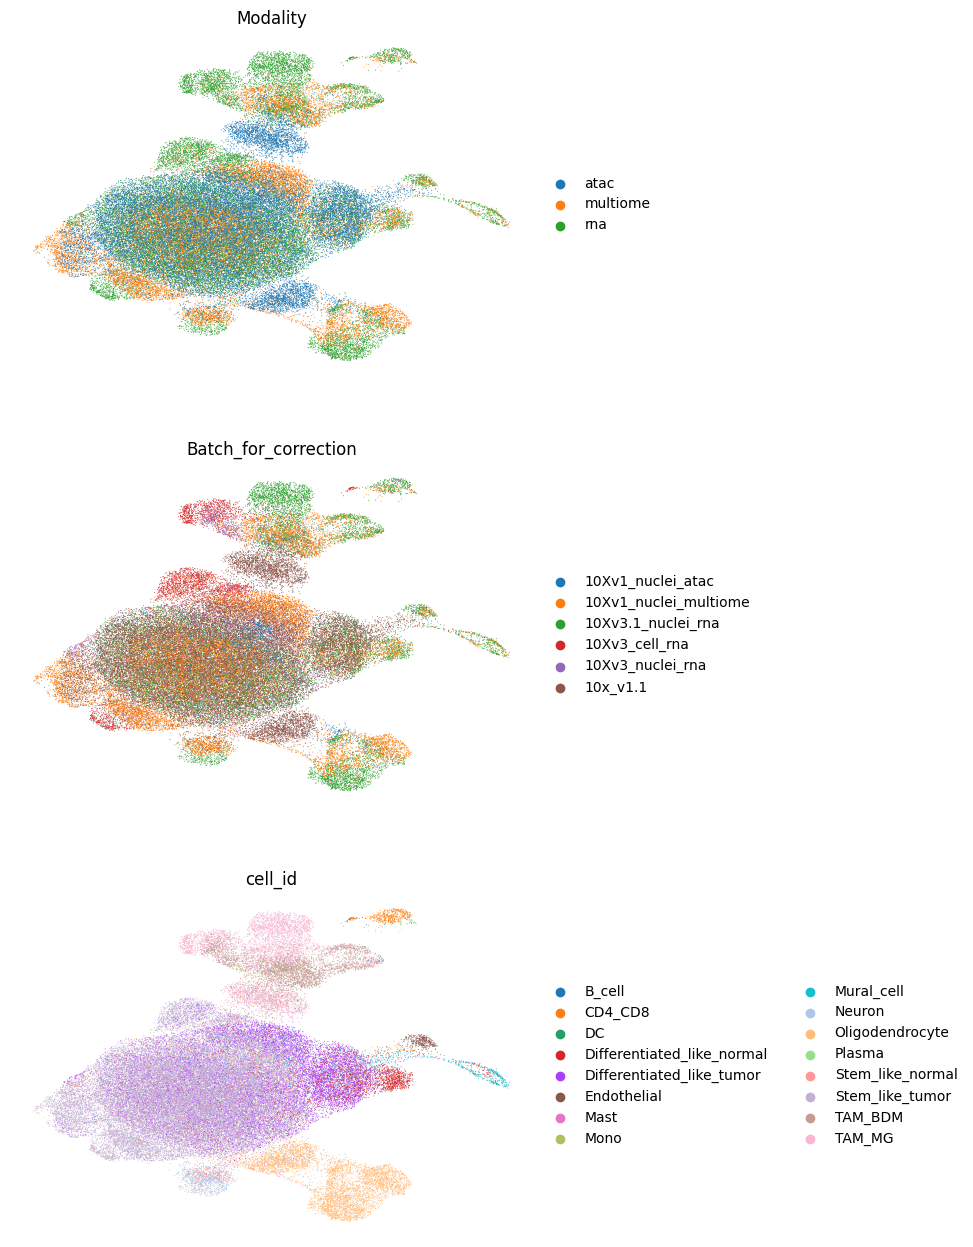

In [38]:
sc.pl.umap(adata, color=['Modality', 'Batch_for_correction', 'cell_id'], ncols=1, frameon=False)

In [39]:
model.save('mosaic_integration/multigrate/trained_multigrate_modality')

In [51]:
adata

AnnData object with n_obs × n_vars = 70797 × 25000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

```
TypeError: expected str, bytes or os.PathLike object, not int

Above error raised while writing key 0 of <class 'h5py._hl.group.Group'> to /
```

In [52]:
del adata.uns

In [54]:
adata.write_h5ad('mosaic_integration/multigrate/trained_multigrate_modality/dmg_atlas_subset_multigrate_modality.h5ad')